V3.1 -  Moving Aircraft And Static Radar

In [3]:
#cbg
# Initialize libraries and functions PC
#%pip install --upgrade numpy
#import matplotlib.pyplot as plt
#from scipy.signal import find_peaks
#import cv2
#from prettytable import PrettyTable
import numpy as np
import math
import random
import time as timess
from IPython.display import clear_output, Markdown, display
from abc import ABC, abstractmethod

def db_to_normal(x):
    return 10**(x/10)

def normal_to_db(x):
    return 10*math.log10(x)

def pdw_tabular_print(pdw,time):
    if(len(pdw)>1):
        display(Markdown('{}<strong>{}</strong>{}'.format('PDW\'s of the recieved pulses in ',str(time//10)+' nano seconds',' are as follows')))
        t = PrettyTable(list(pdw[0].keys()))
        for i in pdw[:]:
            t.add_row(list(i.values()))
        print(t)


current_tick_ns = 0
delta_t_ns = 0
time_1ns=0
time_1ms_ns = 1000000
time_1us_ns = 1000


# base_noise_min=db_to_normal(-1000)
# base_noise_max=db_to_normal(-75)
base_noise_min=db_to_normal(-1000*1000)
base_noise_max=db_to_normal(-75*1000)
ci=0#len(time)//4
cf=10000
cf=10000
fig_x , fig_y = 25 , 2
clrs= 'rgbcmyk'
rand_skew=0
mult = 2

tick_in_ns      =0
previous_tick_ns=0
delta_tick_ns   =0

In [ ]:
# # Initiallize tables
# rf = open("../Radar_G_table_3d.txt", "w")
# # f = open("../RWR_G_table_omni.txt", "w")
# for j in range(5,185,5):#frequency
#     for k in range(360):
#         # print(j,k)
#         # f.write(str(j/10)+' '+str(k))
#         # f.write(' | ')
#         rf.write(str(j/10)+' '+str(k))
#         rf.write(' | ')
#         for i in range(360):
#             if(((i>=0 and i<=90//mult) or (i>=360-(90//mult) and i<360)) and ((k>=0 and k<=90//mult) or (k>=360-(90//mult) and k<360))):
#                 # f.write(str(math.cos(math.radians(0))*math.cos(math.radians(0)))+' ')
#                 rf.write(str(math.cos(math.radians(mult*i))*math.cos(math.radians(mult*k)))+' ')
#             else:
#                 # f.write(str(0)+' ')
#                 rf.write(str(0)+' ')
#         # f.write('\n')
#         rf.write('\n')
# # f.close()
# rf.close()

In [ ]:
# f = open("../angle_table.txt", "w")
# for th in range(-45,45):
#     a1=round(normal_to_db(math.cos(math.radians(45+th))),4)
#     a2=round(normal_to_db(math.cos(math.radians(45-th))),4)
#     f.write(str(round(a2-a1,5))+',')
# th=45
# a1=round(normal_to_db(math.cos(math.radians(45+th))),4)
# a2=round(normal_to_db(math.cos(math.radians(45-th))),4)
# f.write(str(round(a2-a1,5)))
# f.close()

In [4]:
RWR_G_table={}
f = open("./RWR_G_table_omni.txt", "r")
Lines = f.readlines()
for line in Lines:
    tmp=list(line.split())
    tmp_freq=float(tmp[0])
    tmp_azi=int(tmp[1])
    tmp=tmp[3:]
    # print(tmp_freq,tmp_azi,tmp)
    if(tmp_freq not in RWR_G_table):
        RWR_G_table[tmp_freq]=[[]]
    if(len(RWR_G_table[tmp_freq])-1<tmp_azi):
        RWR_G_table[tmp_freq].append([])
    tmp_list=[]
    for i in tmp:
        tmp_list.append(float(i))
    RWR_G_table[tmp_freq][tmp_azi]=tmp_list
f.close()

Radar_G_table={}
f = open("./Radar_G_table_3d.txt", "r")
Lines = f.readlines()
for line in Lines:
    tmp=list(line.split())
    tmp_freq=float(tmp[0])
    tmp_azi=int(tmp[1])
    tmp=tmp[3:]
    # print(tmp_freq,tmp_azi,tmp)
    if(tmp_freq not in Radar_G_table):
        Radar_G_table[tmp_freq]=[[]]
    if(len(Radar_G_table[tmp_freq])-1<tmp_azi):
        Radar_G_table[tmp_freq].append([])
    tmp_list=[]
    for i in tmp:
        tmp_list.append(float(i))
    Radar_G_table[tmp_freq][tmp_azi]=tmp_list
f.close()

f = open("./angle_table.txt", "r")
angle_table=tuple(map(float,f.read().split(',')))
f.close()

In [5]:
class battle_system(ABC):
    def __init__(self):
        pass

    @abstractmethod
    def get(self):
        pass

    @abstractmethod
    def set(self):
        pass

    @abstractmethod
    def ontick(self):
        pass

    def __del__(self):
        pass

In [6]:
class platform(battle_system):
    def __init__(self, pos=(0,0,0),speed=0,onboard_systems=[]):
        super().__init__()
        if(len(pos)==2):
            self.position = list(pos)+[0]
        else:
            self.position = pos
        self.speed = speed
        self.onboard_systems = onboard_systems

    def __del__(self):
        super().__del__()

In [7]:
class aircraft(platform):
    def __init__(self, id,heading=0,speed=10,aircraftWaypoints=[],onboard_systems=[]):
        super().__init__(aircraftWaypoints[0] ,speed,onboard_systems)
        self.id = id                                       # Id of the Aircraft
        self.heading = heading                             # heading of the Aircraft in degrees
        for i in range(len(aircraftWaypoints)):
            if len(aircraftWaypoints[i])==2:
                aircraftWaypoints[i]=list(aircraftWaypoints[i])+[0]
        self.aircraftWaypoints=aircraftWaypoints
        self.next_waypoint=1

    def move_aircraft(self):
        if(len(self.aircraftWaypoints)>1):
            time_diff=1
            cur_pos=list(self.position)
            next_waypoint=self.next_waypoint
            d=math.dist(self.aircraftWaypoints[next_waypoint],cur_pos)
            idx=0
            while(d < (self.speed*time_diff)):
                idx += 1
                next_waypoint += 1
                if (next_waypoint== len(self.aircraftWaypoints)):
                    next_waypoint = 0
                if(idx>len(self.aircraftWaypoints)*2):
                    raise Exception("Aircraft speed is too much")
                d=math.dist(self.aircraftWaypoints[next_waypoint],cur_pos)
            heading=math.degrees(math.atan2(self.aircraftWaypoints[next_waypoint][1] - cur_pos[1],self.aircraftWaypoints[next_waypoint][0] - cur_pos[0]))
            while(heading>=360):
                heading-=360
            while(heading<0):
                heading+=360
            self.heading=heading
            cur_pos[0] += ((self.speed * time_diff) * (self.aircraftWaypoints[next_waypoint][0] - cur_pos[0]) / d)
            cur_pos[1] += ((self.speed * time_diff) * (self.aircraftWaypoints[next_waypoint][1] - cur_pos[1]) / d)
            self.position=cur_pos
            self.next_waypoint=next_waypoint

    def get(self):
        return self.position

    def set(self,speed):
        self.speed=speed

    def ontick(self):
        self.move_aircraft()

    def __del__(self):
        super().__del__()

In [8]:
class sensor(battle_system):
    def __init__(self,host_platform):
        super().__init__()
        self.host_platform = host_platform

    def __del__(self):
        super().__del__()

In [19]:
import math

class radar(sensor):
    def __init__(self, id, pri=500, pwd=10, azimuth=0,
                 radarWaypoints=[], signature_type=['fixed'], host_platform=[]):
        super().__init__(host_platform)
        for i in range(len(radarWaypoints)):
            if len(radarWaypoints[i]) == 2:
                radarWaypoints[i] = list(radarWaypoints[i]) + [0]

        self.id = id
        self.pri = pri
        self.pwd = pwd
        self.Pt = 10**10
        self.freq = 10.0
        self.azimuth = azimuth
        self.elevation = 0
        self.signature_type = signature_type[0]
        self.sig_data = signature_type
        self.impedance = 50
        self.position = radarWaypoints[0] if radarWaypoints else (0, 0, 0)
        self.speed = 10
        self.radarWaypoints = radarWaypoints
        self.next_waypoint = 1

        # --- Added attributes for dtse compatibility ---
        self.time_at_angle_start_ns = 0
        self.time_at_angle_end = 10
        self.duration_per_rotation_ns = 10
        self.ac_angle_start = 0
        self.main_beam_azimuth = azimuth  # keep track of beam direction

    def move_radar(self):
        if len(self.radarWaypoints) > 1:
            time_diff = 1
            cur_pos = list(self.position)
            next_waypoint = self.next_waypoint
            d = math.dist(self.radarWaypoints[next_waypoint], cur_pos)
            idx = 0
            while d < (self.speed * time_diff):
                idx += 1
                next_waypoint += 1
                if next_waypoint == len(self.radarWaypoints):
                    next_waypoint = 0
                if idx > len(self.radarWaypoints) * 2:
                    raise Exception(f"Radar {self.id}'s speed is too much")
                d = math.dist(self.radarWaypoints[next_waypoint], cur_pos)

            cur_pos[0] += ((self.speed * time_diff) *
                           (self.radarWaypoints[next_waypoint][0] - cur_pos[0]) / d)
            cur_pos[1] += ((self.speed * time_diff) *
                           (self.radarWaypoints[next_waypoint][1] - cur_pos[1]) / d)
            self.position = cur_pos
            self.next_waypoint = next_waypoint

    def get(self):
        return self.position

    def set(self, speed=None, azimuth=None, elevation=0):
        if speed is not None:
            self.speed = speed
        if azimuth is not None:
            self.azimuth = azimuth
            self.main_beam_azimuth = azimuth
        self.elevation = elevation

    def ontick(self):
        # Move radar along waypoints
        self.move_radar()
        # Rotate beam azimuth for circular scan
        self.main_beam_azimuth = (self.main_beam_azimuth + 5) % 360

    def __del__(self):
        super().__del__()

In [28]:
class rwr(sensor):
    def __init__(self, number_of_antennas, host_platform):
        super().__init__(host_platform)
        self.number_of_antennas = number_of_antennas
        self.threats = []
        self.pdws = []
        self.emitter_records = []
        self.recieved_power = []
        self.tempAngleDiff = 0

    def get_power(self, radars):
        p = []
        for i in radars:
            p.append(self.Recieved_power(i))
        return p

    def Recieved_power(self, radar):
        # ... your existing logic ...
        return powers

    def get(self):
        return self.recieved_power

    def set(self, power_values=None):   # <-- fixed
        if power_values is not None:
            self.recieved_power = power_values

    def ontick(self, radars=[]):
        self.recieved_power = self.get_power(radars)

    def __del__(self):
        super().__del__()

In [29]:
import math

class dtse:
    def __init__(self, aircraft, radar, rwr,
                 aircraft_speed=0.5, radar_rot_speed=5, radar_speed=0.1,
                 radar_mode="circular", conical_theta_speed=2, conical_rad=5, conical_dis=10,
                 raster_elevation=60, raster_speed=5, palmer_raster_speed=20,
                 palmer_azimuth=-30, palmer_azimuth_speed=10):
        self.aircraft = aircraft
        self.radar = radar
        self.rwr = rwr

        # Simulation parameters
        self.aircraft_speed = aircraft_speed
        self.radar_rot_speed = radar_rot_speed
        self.radar_speed = radar_speed
        self.radar_mode = radar_mode

        # State variables
        self.clockWise = True
        self.raster_clockWise = True
        self.conical_theta = 0
        self.conical_rad = conical_rad
        self.conical_dis = conical_dis
        self.conical_theta_speed = conical_theta_speed
        self.raster_elevation = raster_elevation
        self.raster_speed = raster_speed
        self.palmer_raster_speed = palmer_raster_speed
        self.palmer_azimuth = palmer_azimuth
        self.palmer_azimuth_speed = palmer_azimuth_speed
        self.spiral_increse = True
        self.conical_rad_spiral = conical_rad

        # RWR parameters
        self.RiseState = []
        self.FallState = []
        self.pri = 123
        self.pulseWidth = self.pri
        self.StateFlag1 = 0
        self.StateFlag2 = 0
        self.StateFlag3 = 0
        self.tolerance = 0
        self.shiftCurrent = 0
        self.shiftPrevious = 0
        self.missingCount = 0
        self.ResetFlag = 1

    def fuse(self):
        radar_position = self.radar.position
        aircraft_position = self.aircraft.position
        radar_Pt = self.radar.Pt
        radar_frequency = self.radar.freq

        R = math.dist(radar_position, aircraft_position)
        Lambda = 2

        angle = math.degrees(math.atan2(
            radar_position[1] - aircraft_position[1],
            radar_position[0] - aircraft_position[0]
        )) - self.aircraft.heading

        angle_t = int(angle) % 360

        Radar_G_table = {radar_frequency: [1]*360}
        RWR_G_table = {radar_frequency: [1]*360}

        P = (radar_Pt * Radar_G_table[radar_frequency][angle_t] * (Lambda**2)) / ((4*math.pi*R)**2)

        receivers_n = self.rwr.number_of_antennas
        rwr_angles = [(360/receivers_n)*(1+2*j)/2 for j in range(receivers_n)]

        PowerAtRWR = []
        for idx in range(receivers_n):
            PowerAtRWR.append(abs(P * RWR_G_table[radar_frequency][int(angle - rwr_angles[idx]) % 360]))

        print("Power at RWR: ", PowerAtRWR)
        self.rwr.recieved_power = PowerAtRWR
        return PowerAtRWR

    def driver_run(self, iterations=5600):
        tick_in_ns = 0

        for idx in range(iterations):
            self.aircraft.get()
            self.rwr.get()
            self.radar.get()

            radar_position = self.radar.position
            radar_heading = self.radar.azimuth   # or main_beam_azimuth if you prefer
            aircraft_position = self.aircraft.position
            aircraft_heading = self.aircraft.heading

            PowerAtRWR = self.fuse()   # <-- capture return value
            print("Time: ", idx, " | Power at RWR: ", self.rwr.recieved_power)

            if tick_in_ns >= self.radar.time_at_angle_start_ns and tick_in_ns < self.radar.time_at_angle_end:
                tick_in_ns += 1
            else:
                self.radar.time_at_angle_start_ns += self.radar.duration_per_rotation_ns
                self.radar.time_at_angle_end += self.radar.duration_per_rotation_ns
                tick_in_ns = self.radar.time_at_angle_start_ns
                mbzim = self.radar.ac_angle_start

            self.aircraft.set(self.aircraft_speed)
            self.rwr.set(PowerAtRWR)   # <-- now defined
            self.radar.set()

            self.aircraft.ontick()
            self.rwr.ontick()
            self.radar.ontick()

In [30]:
# --- Scenario Setup for dtse testing ---

# 1. Initialize Aircraft
# Setting up a stationary aircraft for simplicity in this test.
aircraft_test_waypoints = [(700, 700, 0)]
aircraft_test = aircraft(id=0,
                      heading=0,
                      speed=0, # Stationary for this test
                      aircraftWaypoints=aircraft_test_waypoints)

# 2. Initialize RWR (onboard the aircraft)
rwr_test = rwr(number_of_antennas=4, host_platform=aircraft_test)
aircraft_test.onboard_systems = [rwr_test]

# 3. Initialize Radar
# Placing the radar close to the aircraft for visibility.
radar_test_waypoints = [[(750, 700, 0)]]
radar_test = radar(id=1,
                   pri=2000,
                   pwd=1000,
                   azimuth=0, # Initial azimuth
                   radarWaypoints=radar_test_waypoints[0],
                   signature_type=['fixed'])
radar_test.freq = 0.5

# List of radars for dtse
radars_test_list = [radar_test]

# 4. Initialize dtse instance
# Setting radar_mode to 'circular' as requested.
dtse_instance = dtse(aircraft=aircraft_test,
                     radar=radar_test,   # or radar=radars_test_list[0] if you want just one
                     rwr=rwr_test,
                     aircraft_speed=0,
                     radar_mode="circular",
                     radar_rot_speed=30)

# 5. Run dtse.driver_run for 10 iterations
print("Starting dtse simulation for 10 iterations...")
dtse_instance.driver_run(iterations=10)
print("dtse simulation finished.")

Starting dtse simulation for 10 iterations...
Power at RWR:  [101321.18364233777, 101321.18364233777, 101321.18364233777, 101321.18364233777]
Time:  0  | Power at RWR:  [101321.18364233777, 101321.18364233777, 101321.18364233777, 101321.18364233777]
Power at RWR:  [101321.18364233777, 101321.18364233777, 101321.18364233777, 101321.18364233777]
Time:  1  | Power at RWR:  [101321.18364233777, 101321.18364233777, 101321.18364233777, 101321.18364233777]
Power at RWR:  [101321.18364233777, 101321.18364233777, 101321.18364233777, 101321.18364233777]
Time:  2  | Power at RWR:  [101321.18364233777, 101321.18364233777, 101321.18364233777, 101321.18364233777]
Power at RWR:  [101321.18364233777, 101321.18364233777, 101321.18364233777, 101321.18364233777]
Time:  3  | Power at RWR:  [101321.18364233777, 101321.18364233777, 101321.18364233777, 101321.18364233777]
Power at RWR:  [101321.18364233777, 101321.18364233777, 101321.18364233777, 101321.18364233777]
Time:  4  | Power at RWR:  [101321.1836423

In [ ]:
# Main Function

slope=1

#Initialization
radar_mode="circular"
# radar_mode="sector"
# radar_mode="helical"
# radar_mode="raster"
# radar_mode="conical"
# radar_mode="spiral"
# radar_mode="palmer"
# radar_mode="palmerRaster"
# radar_mode="tracking"
search_radars={1}
play_back_speed=1
play_flag=0
resize=1.5
cv2.namedWindow("Visualisation", cv2.WINDOW_NORMAL)
cv2.resizeWindow("Visualisation", int(img.shape[1]/resize), int(img.shape[0]/resize))
tmp_s_r=20
tmp_s_a=20

time=(10**4)*1 #in 1 nano seconds
# time=55 #in 1 nano seconds

visualize=True
idx=0
pdws=[]
pulse_train=[]
pulse_train_f=[]
for j in range(receivers_n):
    pulse_train.append([])
    for i in range(len(radars)):
        pulse_train[-1].append([])
    pulse_train_f.append([])
Emitter_Track_File={}
full_Emitter_Track_File={}
backup_ageinout_Emitter_Track_File={}
backup_actual_Emitter_Track_File={}
rise_fall_flag={}
serach_angles=[]
sn=3
for i in range(sn):
    serach_angles.append(360*i//sn)
serach_angles.insert(1,10)
serach_angles.insert(len(serach_angles),350)
age_in_PFM ={1:3,
             2:3,
             3:5,
             4:5}
age_out_PFM={1:3,
             2:3,
             3:5,
             4:3}

antenna_length = 10
A1_t_table = []
A2_t_table = []
A3_t_table = []
A4_t_table = []
Ax_t_table = []
Ay_t_table = []
Rx_t_table = []
Ry_t_table = []
Ra_t_table = []

# aircraft_0.heading = -50

aircraft_speed = .5
radar_rot_speed= 5
radar_speed = .1
conical_theta_speed=2
conical_theta=0
conical_rad=5
conical_dis=10
clockWise=True
raster_clockWise=True
raster_elevation=60
raster_speed=5
palmer_raster_speed=20
conical_rad_spiral=conical_rad
palmer_azimuth=-30
spiral_increse=True
palmer_azimuth_speed=10

# Adaptive Search Regime Variables
beta = 0   # Radar azimuth at t=0
alpha = 360 # Beam Width
omega = radar_rot_speed # Radar Angular velocity
thetaOffset = 0

RiseState = []
FallState = []
pri = 123
pulseWidth = pri-0
StateFlag1 = 0
StateFlag2 = 0
StateFlag3 = 0
tolerance = 0
shiftCurrent = 0
shiftPrevious = 0
Analysis1 = []
Analysis2 = []
Analysis3 = []
Analysis4 = []
Analysis5 = []
# Main Loop
while(idx<5600):
    print('tick number - ',str(idx+1))
    # Get,Set,Ontick of aircraft
    # print(aircraft_0.get())
    t_pos=aircraft_0.get()
    airc_pos=(int(t_pos[0]),int(t_pos[1]))
    Ax_t_table.append(airc_pos[0])
    Ay_t_table.append(airc_pos[1])
    aircraft_0.set(aircraft_speed)
    aircraft_0.ontick()

    tmp_i=0
    for i in radars:
        t_pos=i.get()
        radar_pos=(int(t_pos[0]),int(t_pos[1]))
        heading_angle=int(math.degrees(math.atan2(airc_pos[1]-radar_pos[1],airc_pos[0]-radar_pos[0])))#+180
        heading_noise_range=0
        if (radar_mode=="circular"):
            clockWise=False
            if(idx < 510 or idx > 600 or True):
                i.set(radar_speed,((i.azimuth+radar_rot_speed)%360) if clockWise else((i.azimuth-radar_rot_speed)%360) ,0)
        elif (radar_mode=="sector"):
            min_sector=30
            max_sector=250
            if(i.azimuth<min_sector+radar_rot_speed and i.azimuth>min_sector-radar_rot_speed):
                clockWise=True
            elif(i.azimuth<max_sector+radar_rot_speed and i.azimuth>max_sector-radar_rot_speed):
                clockWise=False
            i.set(radar_speed,((i.azimuth+radar_rot_speed)%360) if clockWise else((i.azimuth-radar_rot_speed)%360) ,0)
        elif (radar_mode=="helical"):
            clockWise=False
            i.set(radar_speed,((i.azimuth+radar_rot_speed)%360) if clockWise else((i.azimuth-radar_rot_speed)%360) ,(i.elevation+0.07)%360)
        elif (radar_mode=="raster"):
            min_sector=30
            max_sector=250
            min_raster_sector=40
            max_raster_sector=-40
            if(i.azimuth<min_sector+radar_rot_speed and i.azimuth>min_sector-radar_rot_speed):
                clockWise=True
                if raster_clockWise:
                    raster_elevation-=raster_speed
                else:
                    raster_elevation+=raster_speed
            elif(i.azimuth<max_sector+radar_rot_speed and i.azimuth>max_sector-radar_rot_speed):
                clockWise=False
                if raster_clockWise:
                    raster_elevation-=raster_speed
                else:
                    raster_elevation+=raster_speed
            if(i.elevation<min_raster_sector+raster_speed and i.elevation>min_raster_sector-raster_speed):
                raster_clockWise=True
            elif(i.elevation<max_raster_sector+raster_speed and i.elevation>max_raster_sector-raster_speed):
                raster_clockWise=False
            i.set(radar_speed,((i.azimuth+radar_rot_speed)%360) if clockWise else((i.azimuth-radar_rot_speed)%360) ,raster_elevation)
        elif (radar_mode=="conical"):
            conical_theta+=conical_theta_speed
            i.set(radar_speed,180+(math.asin(conical_rad*math.cos(conical_theta*math.pi/180)/math.sqrt(conical_rad**2+conical_dis**2))*180/math.pi),math.asin(conical_rad*math.sin(conical_theta*math.pi/180)/math.sqrt(conical_rad**2+conical_dis**2))*180/math.pi)
        elif (radar_mode=="spiral"):
            conical_theta+=conical_theta_speed
            if(spiral_increse):
                conical_rad_spiral+=.005
            else:
                conical_rad_spiral-=.005
            if(abs(conical_rad_spiral)>conical_rad):
                spiral_increse=not spiral_increse
            i.set(radar_speed,180+(math.asin(abs(conical_rad_spiral)*math.cos(conical_theta*math.pi/180)/math.sqrt(conical_rad_spiral**2+conical_dis**2))*180/math.pi),math.asin(abs(conical_rad_spiral)*math.sin(conical_rad_spiral*math.pi/180)/math.sqrt(conical_rad**2+conical_dis**2))*180/math.pi)
        elif (radar_mode=="palmer"):
            min_sector=30
            max_sector=-40
            conical_theta+=conical_theta_speed
            print(conical_theta,palmer_azimuth)
            if(conical_theta>360):
                if(palmer_azimuth<min_sector+palmer_azimuth_speed//2 and palmer_azimuth>min_sector-palmer_azimuth_speed//2):
                    clockWise=True
                elif(palmer_azimuth<max_sector+palmer_azimuth_speed//2 and palmer_azimuth>max_sector-palmer_azimuth_speed//2):
                    clockWise=False
                conical_theta-=360
                if clockWise:
                    palmer_azimuth-=palmer_azimuth_speed
                else:
                    palmer_azimuth+=palmer_azimuth_speed
            i.set(radar_speed,180+palmer_azimuth+(math.asin(conical_rad*math.cos(conical_theta*math.pi/180)/math.sqrt(conical_rad**2+conical_dis**2))*180/math.pi),math.asin(conical_rad*math.sin(conical_theta*math.pi/180)/math.sqrt(conical_rad**2+conical_dis**2))*180/math.pi)
        elif (radar_mode=="palmerRaster"):
            print(palmer_azimuth,raster_elevation)
            min_sector=30
            max_sector=-40
            min_raster_sector=40
            max_raster_sector=-40
            conical_theta+=conical_theta_speed
            print(conical_theta,palmer_azimuth)
            if(conical_theta>360):
                if(palmer_azimuth<min_sector+palmer_azimuth_speed//2 and palmer_azimuth>min_sector-palmer_azimuth_speed//2):
                    clockWise=True
                    if raster_clockWise:
                        raster_elevation-=palmer_raster_speed
                    else:
                        raster_elevation+=palmer_raster_speed
                elif(palmer_azimuth<max_sector+palmer_azimuth_speed//2 and palmer_azimuth>max_sector-palmer_azimuth_speed//2):
                    clockWise=False
                    if raster_clockWise:
                        raster_elevation-=palmer_raster_speed
                    else:
                        raster_elevation+=palmer_raster_speed
                conical_theta-=360
                if clockWise:
                    palmer_azimuth-=palmer_azimuth_speed
                else:
                    palmer_azimuth+=palmer_azimuth_speed

                if(i.elevation<min_raster_sector+palmer_raster_speed and i.elevation>min_raster_sector-palmer_raster_speed):
                    raster_clockWise=True
                elif(i.elevation<max_raster_sector+palmer_raster_speed and i.elevation>max_raster_sector-palmer_raster_speed):
                    raster_clockWise=False
            i.set(radar_speed,180+palmer_azimuth+(math.asin(conical_rad*math.cos(conical_theta*math.pi/180)/math.sqrt(conical_rad**2+conical_dis**2))*180/math.pi),math.asin(conical_rad*math.sin(conical_theta*math.pi/180)/math.sqrt(conical_rad**2+conical_dis**2))*180/math.pi+raster_elevation)
        else:
            i.set(radar_speed,random.randint(heading_angle-heading_noise_range,heading_angle+heading_noise_range))
        if(tmp_i==0):
            Rx_t_table.append(radar_pos[0])
            Ry_t_table.append(radar_pos[1])
            Ra_t_table.append(i.azimuth)
        i.ontick()
        tmp_i+=1

    # Get,Set,Ontick of RWR
    for i in aircraft_0.onboard_systems:
        rwr_0.set()
        rwr_0.ontick(radars)
        t_temp=rwr_0.get()[0]

        # print(len(FallState))
        if(len(FallState)<3):
            if((t_temp[0] > -85) or (t_temp[1] > -85) or (t_temp[2] > -85) or (t_temp[3] > -85)):
                if(StateFlag1==0):
                    RiseState.append(idx-1-tolerance)
                    # print('Tick - ',idx)
                    # print(RiseState)
                    # print(FallState)
                    # cv2.waitKey(0)
                StateFlag1 = 1
                # print('High')
            else:
                if(StateFlag1==1):
                    FallState.append(idx-0+tolerance)
                    # print('Tick - ',idx)
                    # print(RiseState)
                    # print(FallState)
                    # cv2.waitKey(0)
                StateFlag1 = 0
                # print('Low')

            ResetFlag=1
            shiftPrevious = 0
            shiftCurrent = 0
        else:
            if(ResetFlag):
                if(abs((FallState[2]-FallState[1]) - (FallState[1]-FallState[0]))<2 and abs((RiseState[2]-RiseState[1]) - (RiseState[1]-RiseState[0]))<2):
                    ResetFlag = 0
                    pri = FallState[2]-FallState[1]
                    pulseWidth = FallState[2] - RiseState[2]#%pri
                    # print(pri,pulseWidth)
                    # cv2.waitKey(0)
                else:
                    ResetFlag = 0
                    FallState.pop(0)
                    RiseState.pop(0)
                    # print(FallState,RiseState)
                    # cv2.waitKey(0)
                shiftPrevious = 0
                shiftCurrent = 0

        if (((idx-(FallState[-1] if len(FallState)>0 else 0)-shiftCurrent)+tolerance+1)%pri > pulseWidth and ((idx-(FallState[-1] if len(FallState)>0 else 0)-shiftCurrent)+tolerance+1)%pri<pulseWidth+10):
            shiftCurrent = shiftPrevious
            A1_t_table.append(-90)
            A2_t_table.append(-90)
            A3_t_table.append(-90)
            A4_t_table.append(-90)

        elif (((idx-(FallState[-1] if len(FallState)>0 else 0)-shiftCurrent)+tolerance+1)%pri > pri - pulseWidth):
            if(StateFlag2 == 0):
                # print('Rise')
                # cv2.waitKey(0)
                pass
            StateFlag2 = 1
            A1_t_table.append(t_temp[0])
            A2_t_table.append(t_temp[1])
            A3_t_table.append(t_temp[2])
            A4_t_table.append(t_temp[3])

            if((t_temp[0] > -85) or (t_temp[1] > -85) or (t_temp[2] > -85) or (t_temp[3] > -85)):
                StateFlag3 += 1
        else:
            if(StateFlag2 == 1):
                # print('Fall',StateFlag3,idx)
                # cv2.waitKey(0)
                if(StateFlag3==0):
                    missingCount +=1
                    if(missingCount>2):
                        FallState.clear()
                        RiseState.clear()
                        pri = 123
                        pulseWidth = pri-0
                        shiftPrevious = 0
                        shiftCurrent = 0
                else:
                    if(StateFlag3<pulseWidth-3):
                        # print(StateFlag3,pulseWidth)
                        if((A1_t_table[-3] > -85) or (A2_t_table[-3] > -85) or (A3_t_table[-3] > -85) or (A4_t_table[-3] > -85)):
                            shiftPrevious += ( pulseWidth - StateFlag3 - 2 )
                            # pass
                        else:
                            shiftPrevious -= ( pulseWidth - StateFlag3 - 2 )
                            # pass
                        # cv2.waitKey(0)
                    missingCount = 0
            StateFlag2 = 0
            StateFlag3 = 0

            A1_t_table.append(-90)
            A2_t_table.append(-90)
            A3_t_table.append(-90)
            A4_t_table.append(-90)

            # A1_t_table.append(t_temp[0])
            # A2_t_table.append(t_temp[1])
            # A3_t_table.append(t_temp[2])
            # A4_t_table.append(t_temp[3])

    # Visualization
    img=np.zeros(img.shape,np.uint8)
    for j in range(receivers_n):
        cv2.line(img,airc_pos,(int(airc_pos[0]+(antenna_length*math.cos(math.radians(aircraft_0.heading+(360/receivers_n)*(1+2*j)/2)))),int(airc_pos[1]+(antenna_length*math.sin(math.radians(aircraft_0.heading+(360/receivers_n)*(1+2*j)/2))))),(0,0,255),2)
    cv2.circle(img,airc_pos,5,(0,255,0),-1)
    airc_head=(int(airc_pos[0]+(antenna_length*1.5*math.cos(math.radians(aircraft_0.heading))))
              ,int(airc_pos[1]+(antenna_length*math.sin(math.radians(aircraft_0.heading)))))
    cv2.line(img,airc_pos,airc_head,(0,255,0),4)
    #Aircraft waypoints
    # for j in range(len(aircraft_0.aircraftWaypoints)-1):
    #     cv2.line(img,aircraft_0.aircraftWaypoints[j],aircraft_0.aircraftWaypoints[j+1],(255,255,0),2)
    # cv2.line(img,aircraft_0.aircraftWaypoints[-1],aircraft_0.aircraftWaypoints[0],(255,255,0),2)
    for j in range(len(radars)):
        # adding the radars to the image
        radar_pos=(int(radars[j].position[0]),int(radars[j].position[1]))
        cv2.circle(img,radar_pos,7,(255,155,0),-1)
        cv2.putText(img,str(radars[j].id),(radar_pos[0]+20,radar_pos[1]),cv2.FONT_HERSHEY_SIMPLEX,1,(255,255,255),1,cv2.LINE_AA)
        cv2.line(img,radar_pos,(int(radar_pos[0]+(tmp_s_r*math.cos(math.radians(radars[j].azimuth)))),int(radar_pos[1]+(tmp_s_r*math.sin(math.radians(radars[j].azimuth))))),(0,0,255),2)
    image=cv2.putText(img,'tick number - '+str(idx),(img.shape[1]*6//10,img.shape[0]*1//10),cv2.FONT_HERSHEY_SIMPLEX,1,(255,255,255),2,cv2.LINE_AA)
    cv2.imshow('Visualisation',img)
    idx+=1
    # break
    if(play_flag):
        # if(idx<15 or (idx>92 and idx<98) or (idx>99 and idx<107)):
        if((idx>4 and idx<10)):
            quit_k=cv2.waitKey(play_back_speed) & 0xFF
            # quit_k=cv2.waitKey(0)&0xFF
        else:
            quit_k=cv2.waitKey(play_back_speed) & 0xFF
    else:
        quit_k = cv2.waitKey(0) & 0xFF
    clear_output(wait=True)
    if quit_k == ord('q'):
        break
    if quit_k == ord('p'):
        play_flag=False
    if quit_k == ord('l'):
        play_flag=True
# cv2.imwrite('Visualisation.jpg',img)
cv2.destroyAllWindows()

tick number -  5600


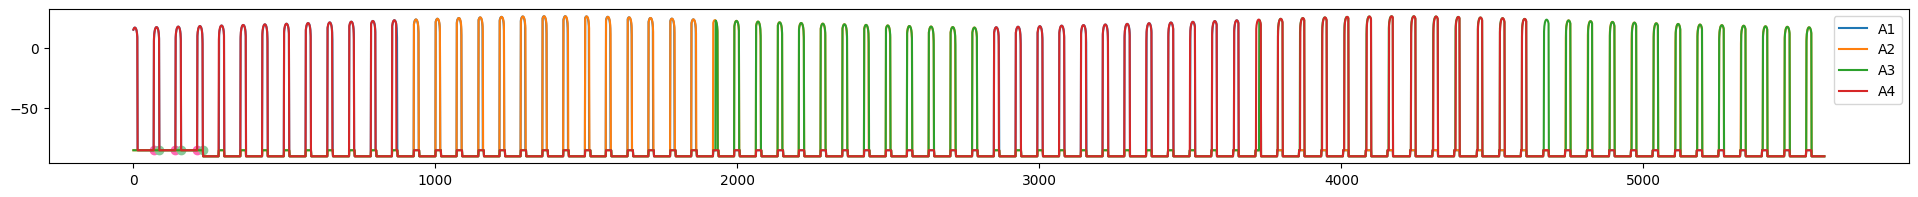

Main Table


In [ ]:
plt.figure(figsize=(24 , 2))
plt.plot(A1_t_table,label='A1')
plt.plot(A2_t_table,label='A2')
plt.plot(A3_t_table,label='A3')
plt.plot(A4_t_table,label='A4')
for i in RiseState:
    plt.scatter(i,-85, color = 'hotpink')
for i in FallState:
    plt.scatter(i,-85, color = '#88c999')
plt.legend()
plt.show()

print('Main Table')
t = PrettyTable(['Tick','Aircraft X', 'Aircraft Y','Radar X','Radar Y','Radar Azimuth','A1 ','A2'])
for i in range(len(A1_t_table)):
    t.add_row([i,Ax_t_table[i],Ay_t_table[i],Rx_t_table[i],Ry_t_table[i],Ra_t_table[i],A1_t_table[i],A2_t_table[i]])
# print(t)

In [ ]:
A1_t_peak, _ = find_peaks(A1_t_table)
A2_t_peak, _ = find_peaks(A2_t_table)
A3_t_peak, _ = find_peaks(A3_t_table)
A4_t_peak, _ = find_peaks(A4_t_table)
# t_peaks=A1_t_peak+A2_t_peak+A3_t_peak+A4_t_peak
t_peaks=list(A1_t_peak)+list(A2_t_peak)
t_peaks = sorted(set(t_peaks), key = lambda ele: list(t_peaks).count(ele))
t_peaks.sort()

# Visualization
print('Filtered Table just for detecting peaks in both A1 and A2')
t = PrettyTable(['Tick','Aircraft X', 'Aircraft Y','Radar X','Radar Y','Radar Azimuth','A1 ','A2'])
for i in t_peaks:
    t.add_row([i,Ax_t_table[i],Ay_t_table[i],Rx_t_table[i],Ry_t_table[i],Ra_t_table[i],A1_t_table[i],A2_t_table[i]])
print(t)

Filtered Table just for detecting peaks in both A1 and A2
+------+------------+------------+---------+---------+---------------+--------------------+--------------------+
| Tick | Aircraft X | Aircraft Y | Radar X | Radar Y | Radar Azimuth |        A1          |         A2         |
+------+------------+------------+---------+---------+---------------+--------------------+--------------------+
|  5   |    1100    |    1397    |   1350  |   700   |      109      | 16.646148887877438 |        -85         |
|  77  |    1100    |    1361    |   1350  |   700   |      109      | 17.049088222910044 |        -85         |
| 149  |    1100    |    1325    |   1350  |   700   |      109      | 17.46363029222604  |        -85         |
| 220  |    1100    |    1290    |   1350  |   700   |      114      | 17.905809082592867 |        -85         |
| 291  |    1100    |    1254    |   1350  |   700   |      119      | 18.29476020750922  |        -85         |
| 292  |    1100    |    1254    |   1

In [ ]:
# freqs=pdws[-1]['Frequency (GHz)'][0][:-1]
# freq_2=[]
# freq_3=[]
# for i in range(len(freqs)):
#     if(freqs[i]>=100):
#         print(freqs[i],end=',')
#     else:
#         print(freqs[i],end=' ,')
# print()
# print(end='  ')
# for i in range(len(freqs)-1):
#     temp=round(100/freqs[i],2)
#     if(temp>=100):
#         print(temp,end=',')
#     elif(temp>=10):
#         print(temp,end=' ,')
#     else:
#         print(temp,end=' , ')
#     freq_2.append(temp)
# print()
# print(end='  ')
# for i in range(len(freq_2)-1):
#     temp=freq_2[i]-freq_2[i+1]
#     if(temp>=100):
#         print(temp,end=',')
#     elif(temp>=10):
#         print(temp,end=' ,')
#     else:
#         print(temp,end=' , ')

In [ ]:
# # Display independent Pulse Train
# import matplotlib.pyplot as plt

# time_l=[*range(len(pulse_train_f[0]))]
# ci=0#8*len(time_l)//9
# cf=len(time_l)//1

# fig_x , fig_y = 25 , 2
# clrs= 'rgbcmyk'

# for i in pulse_train:
#     plt.figure(figsize=(fig_x , fig_y))
#     jdx=0
#     for j in i:
#         jdx+=1
#         plt.plot(time_l[ci:cf],j[ci:cf], color=clrs[jdx-1], label=str(jdx))
#     plt.legend()
#     plt.xlabel("independent input pulses")
#     # plt.ylim([0, ylim])
#     # plt.savefig("independent"+str(jdx)+".jpg")
#     plt.show()

In [ ]:
# # Display interleaved Pulse Train

# import matplotlib.pyplot as plt

# time_l=[*range(len(pulse_train_f[0]))]
# ci=0#len(time)//4
# cf=len(time_l)//1

# fig_x , fig_y = 25 , 2
# clrs= 'rgbcmyk'

# # for i in pulse_train_f:
# #     print(i)
# # for i in pulse_train_f:
# for i in pulse_train_f:
#     plt.figure(figsize=(fig_x , fig_y))
#     plt.plot(time_l[ci:cf],i[ci:cf], color=clrs[0])
#     plt.xlabel("interleaved pulses")
#     # plt.ylim([0, ylim])
#     # plt.savefig("independent"+str(jdx)+".jpg")
#     plt.show()
# # xt = pulse_train_f[1]
# # fxt = np.fft.fft(xt)
# # # fxt = np.real(fxt)
# # fft = (np.abs(fxt)**1)[:len(fxt)//2]
# # fft = fft[:]
# # plt.figure(figsize=(fig_x , fig_y))
# # plt.plot(time_l[ci:len(fft)],fft[ci:cf], color=clrs[0])
# # plt.title("Magnitude of the FT of x(t)")
# # plt.ylabel("Magnitude")
# # plt.xlabel("Frequency Index")
# # # plt.xticks(np.arange(0, len(fft), 50//fac))
# # plt.show()

In [ ]:
# # Aircraft and radar waypoints

# def draw_rectangle(event,x,y,flags,param):
#     global pt_clicked
#     if event == cv2.EVENT_LBUTTONDOWN:
#         pt1 = (x,y)
#         pt_clicked.append(pt1)
#         cv2.circle(frame, center=pt1, radius=3, color=(255,255,255), thickness=-1)

# cv2.namedWindow("Test", cv2.WINDOW_NORMAL)
# cv2.setMouseCallback('Test', draw_rectangle)
# resize=1.5
# cv2.resizeWindow("Test", int(img.shape[1]/resize), int(img.shape[0]/resize))

# pt_clicked=[]

# frame = np.zeros(img.shape, np.uint8)
# while True:
#     for i in radars:
#         radar_pos=(int(i.position[0]),int(i.position[1]))
#         heading_angle=int(math.degrees(math.atan2(airc_pos[1]-radar_pos[1],airc_pos[0]-radar_pos[0])))#+180
#         heading_noise_range=0
#         i.heading=random.randint(heading_angle-heading_noise_range,heading_angle+heading_noise_range)
#         cv2.circle(frame, radar_pos, 5, (255,0,0), -1)
#         # cv2.circle(frame, radar_pos, 1200, (255,0,255), 1)
#         cv2.line(frame, radar_pos,
#                  (int(radar_pos[0]+(tmp_s_r*math.cos(math.radians(i.heading)))),
#                   int(radar_pos[1]+(tmp_s_r*math.sin(math.radians(i.heading))))), (0,0,255), 2)
#     # for j in range(90):
#     #     cv2.circle(frame,(int(1400-(1300*math.cos(math.radians(j)))),int(1400-(1300*math.sin(math.radians(j))))), 5, (255,255,255), -1)
#     cv2.imshow('Test', frame)
#     qk=cv2.waitKey(1) & 0xFF
#     if qk == ord('q'):
#         print(pt_clicked)
#         break
#     if qk == ord('r'):
#         pt_clicked=[]
#         frame = np.zeros(img.shape, np.uint8)
#     if qk == ord('s'):
#         print(pt_clicked)
# cv2.destroyAllWindows()

In [ ]:
# tmp_list=[]
# for i in range(90):
#     tmp_list.append((int(1400-(1300*math.cos(math.radians(i)))),int(1400-(1300*math.sin(math.radians(i))))))
# print(tmp_list)

In [ ]:
# # Radar coordinates

# def draw_rectangle(event,x,y,flags,param):
#     global pt_clicked
#     if event == cv2.EVENT_LBUTTONDOWN:
#         pt1 = (float(x),float(y))
#         pt_clicked.append(pt1)
#         cv2.circle(frame, center=(int(pt1[0]),int(pt1[1])), radius=5, color=(0,0,255), thickness=-1)

# cv2.namedWindow('Test')
# cv2.setMouseCallback('Test', draw_rectangle)

# pt_clicked=[]

# frame = np.zeros(img.shape, np.uint8)
# while True:
#     cv2.imshow('Test', frame)
#     qk=cv2.waitKey(1) & 0xFF
#     if qk == ord('q'):
#         print(pt_clicked)
#         break
#     if qk == ord('r'):
#         pt_clicked=[]
#         frame = np.zeros(img.shape, np.uint8)
#     if qk == ord('s'):
#         print(pt_clicked)
# cv2.destroyAllWindows()

In [ ]:
# frame = np.zeros((500,2000,3), np.uint8)
# while True:
#     cv2.imshow('Test', frame)
#     qk=cv2.waitKey(1) & 0xFF
#     if qk == ord('q'):
#         break
# cv2.destroyAllWindows()

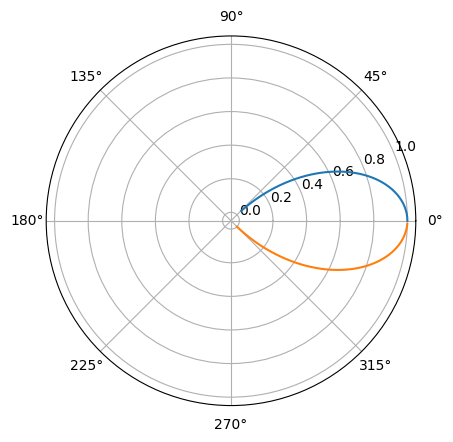

In [ ]:
tm = np.arange(0,360,1)

input_wave = np.cos(mult*np.radians(tm))
plt.polar(np.radians(tm)[:90//mult],input_wave[:90//mult])
plt.polar(np.radians(tm)[len(input_wave)-(90//mult):],input_wave[len(input_wave)-(90//mult):])
plt.show()